<a href="https://colab.research.google.com/github/utjimmyx/python/blob/main/Exponential_Distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Imagine we're analyzing customer service calls at a help desk where
## calls arrive following an exponential distribution
## with an average rate of 3 calls per hour (λ = 3).
## Find the probability of waiting between 10 and 20 minutes for the next call
## Problem: Find P(10 < X < 20 minutes) where calls arrive at λ = 3 per hour
import numpy as np
from scipy.stats import expon
import matplotlib.pyplot as plt

# ============================================================================
# STEP 1: DEFINE PARAMETERS
# ============================================================================

lambda_per_hour = 3  # Average rate: 3 calls per hour
lambda_per_minute = lambda_per_hour / 60  # Convert to calls per minute
print(f"λ (rate parameter): {lambda_per_minute} calls per minute")
print(f"μ (mean time between calls): {1/lambda_per_minute} minutes\n")

# Time window of interest
t1 = 10  # Lower bound (minutes)
t2 = 20  # Upper bound (minutes)


λ (rate parameter): 0.05 calls per minute
μ (mean time between calls): 20.0 minutes



In [ ]:
# ============================================================================
# STEP 2: CALCULATE USING SCIPY (RECOMMENDED)
# ============================================================================
print("=" * 70)
print("METHOD 1: Using scipy.stats.expon")
print("=" * 70)

# Create exponential distribution object
# Note: scipy uses scale = 1/lambda, so we need to convert
scale = 1 / lambda_per_minute  # scale parameter
exp_dist = expon(scale=scale)

# Calculate probability P(10 < X < 20)
prob_scipy = exp_dist.cdf(t2) - exp_dist.cdf(t1)
print(f"\nP(10 < X < 20) = F(20) - F(10)")
print(f"               = {exp_dist.cdf(t2):.6f} - {exp_dist.cdf(t1):.6f}")
print(f"               = {prob_scipy:.6f}")
print(f"               ≈ {prob_scipy*100:.2f}%\n")

# Also show individual probabilities
prob_at_10 = exp_dist.cdf(t1)
prob_at_20 = exp_dist.cdf(t2)
print(f"P(X ≤ 10) = {prob_at_10:.6f} ({prob_at_10*100:.2f}%)")
print(f"P(X ≤ 20) = {prob_at_20:.6f} ({prob_at_20*100:.2f}%)")


METHOD 1: Using scipy.stats.expon

P(10 < X < 20) = F(20) - F(10)
               = 0.632121 - 0.393469
               = 0.238651
               ≈ 23.87%

P(X ≤ 10) = 0.393469 (39.35%)
P(X ≤ 20) = 0.632121 (63.21%)


In [ ]:
# ============================================================================
# STEP 3: CALCULATE USING MANUAL FORMULA
# ============================================================================
print("\n" + "=" * 70)
print("METHOD 2: Using Manual Calculation")
print("=" * 70)

# CDF formula: F(t) = 1 - e^(-λt)
# P(a < X < b) = F(b) - F(a) = [1 - e^(-λb)] - [1 - e^(-λa)]
#              = e^(-λa) - e^(-λb)

cdf_10 = 1 - np.exp(-lambda_per_minute * t1)
cdf_20 = 1 - np.exp(-lambda_per_minute * t2)
prob_manual = cdf_20 - cdf_10

print(f"\nFormula: P(a < X < b) = e^(-λa) - e^(-λb)")
print(f"         P(10 < X < 20) = e^(-0.05×10) - e^(-0.05×20)")
print(f"                        = e^(-0.5) - e^(-1.0)")
print(f"                        = {np.exp(-lambda_per_minute * t1):.6f} - {np.exp(-lambda_per_minute * t2):.6f}")
print(f"                        = {prob_manual:.6f}")
print(f"                        ≈ {prob_manual*100:.2f}%\n")



METHOD 2: Using Manual Calculation

Formula: P(a < X < b) = e^(-λa) - e^(-λb)
         P(10 < X < 20) = e^(-0.05×10) - e^(-0.05×20)
                        = e^(-0.5) - e^(-1.0)
                        = 0.606531 - 0.367879
                        = 0.238651
                        ≈ 23.87%



In [ ]:
# ============================================================================
# STEP 4: COMPLEMENTARY PROBABILITIES
# ============================================================================
print("=" * 70)
print("COMPLEMENTARY PROBABILITIES")
print("=" * 70)

prob_less_10 = exp_dist.cdf(t1)
prob_greater_20 = 1 - exp_dist.cdf(t2)

print(f"\nP(X < 10 minutes) = {prob_less_10:.6f} ({prob_less_10*100:.2f}%)")
print(f"P(10 ≤ X ≤ 20)    = {prob_scipy:.6f} ({prob_scipy*100:.2f}%)")
print(f"P(X > 20 minutes) = {prob_greater_20:.6f} ({prob_greater_20*100:.2f}%)")
print(f"Total             = {prob_less_10 + prob_scipy + prob_greater_20:.6f}")



COMPLEMENTARY PROBABILITIES

P(X < 10 minutes) = 0.393469 (39.35%)
P(10 ≤ X ≤ 20)    = 0.238651 (23.87%)
P(X > 20 minutes) = 0.367879 (36.79%)
Total             = 1.000000


In [ ]:
# ============================================================================
# STEP 5: KEY STATISTICS
# ============================================================================
print("\n" + "=" * 70)
print("DISTRIBUTION STATISTICS")
print("=" * 70)

mean = exp_dist.mean()
variance = exp_dist.var()
std_dev = exp_dist.std()
median = exp_dist.median()

print(f"\nMean (Expected value): {mean:.4f} minutes")
print(f"Median: {median:.4f} minutes")
print(f"Variance: {variance:.4f}")
print(f"Standard Deviation: {std_dev:.4f} minutes")
print(f"\nInterpretation: On average, we wait {mean:.2f} minutes for the next call")



DISTRIBUTION STATISTICS

Mean (Expected value): 20.0000 minutes
Median: 13.8629 minutes
Variance: 400.0000
Standard Deviation: 20.0000 minutes

Interpretation: On average, we wait 20.00 minutes for the next call


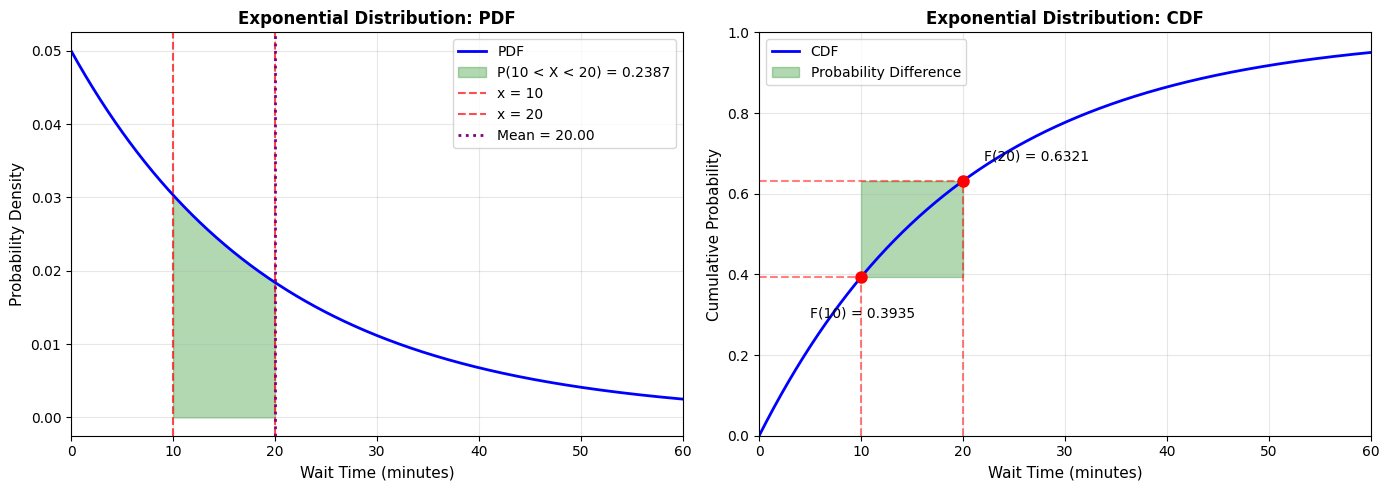

In [ ]:
# ============================================================================
# STEP 6: VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PDF with shaded region
x = np.linspace(0, 60, 1000)
pdf = exp_dist.pdf(x)

axes[0].plot(x, pdf, 'b-', linewidth=2, label='PDF')
x_fill = np.linspace(t1, t2, 100)
axes[0].fill_between(x_fill, exp_dist.pdf(x_fill), alpha=0.3, color='green',
                      label=f'P(10 < X < 20) = {prob_scipy:.4f}')
axes[0].axvline(t1, color='red', linestyle='--', alpha=0.7, label=f'x = {t1}')
axes[0].axvline(t2, color='red', linestyle='--', alpha=0.7, label=f'x = {t2}')
axes[0].axvline(mean, color='purple', linestyle=':', linewidth=2, label=f'Mean = {mean:.2f}')
axes[0].set_xlabel('Wait Time (minutes)', fontsize=11)
axes[0].set_ylabel('Probability Density', fontsize=11)
axes[0].set_title('Exponential Distribution: PDF', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 60)

# Plot 2: CDF with marked points
cdf = exp_dist.cdf(x)
axes[1].plot(x, cdf, 'b-', linewidth=2, label='CDF')
axes[1].plot([t1, t2], [exp_dist.cdf(t1), exp_dist.cdf(t2)], 'ro', markersize=8)
axes[1].hlines([exp_dist.cdf(t1), exp_dist.cdf(t2)], 0, [t1, t2],
               colors='red', linestyles='--', alpha=0.5)
axes[1].vlines([t1, t2], 0, [exp_dist.cdf(t1), exp_dist.cdf(t2)],
               colors='red', linestyles='--', alpha=0.5)
axes[1].fill_between([t1, t2], exp_dist.cdf(t1), exp_dist.cdf(t2),
                      alpha=0.3, color='green', label=f'Probability Difference')
axes[1].annotate(f'F(10) = {exp_dist.cdf(t1):.4f}', xy=(t1, exp_dist.cdf(t1)),
                xytext=(t1-5, exp_dist.cdf(t1)-0.1), fontsize=10)
axes[1].annotate(f'F(20) = {exp_dist.cdf(t2):.4f}', xy=(t2, exp_dist.cdf(t2)),
                xytext=(t2+2, exp_dist.cdf(t2)+0.05), fontsize=10)
axes[1].set_xlabel('Wait Time (minutes)', fontsize=11)
axes[1].set_ylabel('Cumulative Probability', fontsize=11)
axes[1].set_title('Exponential Distribution: CDF', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 60)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()
